# 05 — The cost model (WS5)

**Feeds C2, C9, C13, C15.** No Milvus, no API spend. This notebook is
arithmetic over numbers that already exist as measurements, plus prices
fetched today with a source URL and date.

**Inputs (all committed, cited by path in the cell that reads them):**

| what | file | measured by |
|---|---|---|
| live vs index per-query tokens, code search (agentic / indexed / stuffed / parametric, n=40; S/M/L scaling subsets n=10) | `results/ws6a/{summary,runs,scaling,repo_stats,index_cost}.csv`, `data/ws6a_prefix_manifest.json` | WS6a |
| live vs index per-query tokens, agent memory (replay cached+uncached vs memsearch at 98k / 392k / 1.22M tokens) | `results/ws6b/{summary_s,summary_m,summary_l,runs,corpus_stats,index_cost,skip_rate}.csv` | WS6b |
| live vs index per-query tokens, code search on an UNSEEN repository (agentic / indexed / indexed_topk3, 37-question panel at S/M/L; parametric floor at L) | `results/ws6c/{scaling,scaling_corpus_stats,index_cost,runs}.csv` | WS9 |
| index footprint multipliers (measured loaded bytes vs raw fp32, 10M) | `results/ws2/curves_10m.csv`, `results/ws3/dim_verdict_10m.csv` | WS2, WS3 |
| measured recall@10 of the priced index arm (`pca_uc_384_sq8`) | `results/ws4/summary.csv` | WS4 |
| prices | fetched 2026-09-07, written to `results/ws5/pricing.csv` by the assumptions cell | this notebook |

**House rules honoured here:** every assumption is a named variable in one
cell; no token count is a guess; the model must **postdict** the measured
points within ±10% before it is allowed to draw a line between them; any
crossover is a bracket between computed points, never a fitted intersection;
the C9 test is declared in a markdown cell *before* the cell that computes it.

Outputs (each written by exactly one cell): `results/ws5/pricing.csv`,
`postdiction_gate.csv`, `break_even.csv`, `churn.csv`, `sensitivity.csv`,
`chart_break_even.png`, `chart_churn.png`, `chart_sensitivity.png`.

Runtime: seconds. RAM: trivial.


In [1]:
# ---- setup ------------------------------------------------------------------
import dataclasses, json, math, sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
esc = lambda t: t.replace("$", r"\$")   # chart text carries $ prices; keep them out of mathtext
import pandas as pd

from benchlib import config, manifest, cost_model

R = config.RESULTS_DIR
OUT = config.ws5_dir(); OUT.mkdir(exist_ok=True)

# --- WS6a (code search) ---
ws6a_summary = pd.read_csv(R / "ws6a" / "summary.csv").set_index("arm")
ws6a_runs    = pd.read_csv(R / "ws6a" / "runs.csv")
ws6a_scaling = pd.read_csv(R / "ws6a" / "scaling.csv")
ws6a_repo    = pd.read_csv(R / "ws6a" / "repo_stats.csv").set_index("scope")
ws6a_index   = pd.read_csv(R / "ws6a" / "index_cost.csv").set_index("scope")
ws6a_prefix  = json.loads((config.DATA_DIR / "ws6a_prefix_manifest.json").read_text())

# --- WS6b (agent memory) ---
ws6b_summary = {s: pd.read_csv(R / "ws6b" / f"summary_{s}.csv").set_index("arm")
                for s in ("s", "m", "l")}
ws6b_runs    = pd.read_csv(R / "ws6b" / "runs.csv")
ws6b_stats   = pd.read_csv(R / "ws6b" / "corpus_stats.csv").set_index("size")
ws6b_index   = pd.read_csv(R / "ws6b" / "index_cost.csv").set_index("size")
ws6b_skip    = pd.read_csv(R / "ws6b" / "skip_rate.csv").set_index("variant")

# --- WS9 (code search on an UNSEEN corpus: agentic-hil) ---
ws9_scaling = pd.read_csv(R / "ws6c" / "scaling.csv")
ws9_stats   = pd.read_csv(R / "ws6c" / "scaling_corpus_stats.csv").set_index("scope")
ws9_index   = pd.read_csv(R / "ws6c" / "index_cost.csv").set_index("scope")
ws6c_runs   = pd.read_csv(R / "ws6c" / "runs.csv")
WS9_PANEL   = sorted(set(ws9_scaling.qid))
assert len(WS9_PANEL) == 37, f"WS9 panel is {len(WS9_PANEL)}, expected 37"

# --- WS2 / WS3 footprints, WS4 recall ---
ws2_curves = pd.read_csv(R / "ws2" / "curves_10m.csv")
ws3_dim    = pd.read_csv(R / "ws3" / "dim_verdict_10m.csv").set_index("arm")
ws4        = pd.read_csv(R / "ws4" / "summary.csv")

assert (ws6b_runs.status.isin(["ok", "window_exceeded"])).all()
print("inputs loaded:",
      f"ws6a runs={len(ws6a_runs)}, ws6b runs={len(ws6b_runs)}, ws9 rows={len(ws9_scaling)}, "
      f"ws2 rows={len(ws2_curves)}, ws3 arms={len(ws3_dim)}, ws4 rows={len(ws4)}")


inputs loaded: ws6a runs=160, ws6b runs=125, ws9 rows=333, ws2 rows=33, ws3 arms=3, ws4 rows=48


## Every assumption lives here, nowhere else

Three **providers**, not three Claude price points:

1. **Claude API** — Sonnet 5, the model every WS6 token count was measured
   on. $2 / $10 per MTok, 1h cache write 2×, cache read 0.1×. Re-verified at
   the pricing page today; the page now states the introductory price is
   permanent and the $3/$15 increase will not occur.
2. **OpenAI API** — `gpt-5.6-terra`, the OpenAI tier whose list price sits
   at Sonnet 5's ($2 in). Cached input 0.1×, **no cache-write surcharge**,
   and a long-context tier that re-prices the *whole request* above 272K
   input tokens — which WS6b's M and L points cross. Max input 922K, so the
   two ~960K live points (WS6a stuffed, WS6b replay at L) cannot run there.
3. **Open-weight, self-hosted** — $/MTok derived, not quoted: a rented
   H100 $/hour ÷ a benchmarked vLLM token rate. The derivation is printed
   below with both sources. Context 128K, so only the smallest live points
   fit.

Everything else — embedding price, instance price, the Milvus sizing
approach, the measured footprints, the priced arm's WS4 recall — is loaded or set here and
written to `pricing.csv` with URL + date.


In [2]:
# ---- ASSUMPTIONS: the only cell that may contain a price or a choice ----------
FETCHED = "2026-09-07"

# --- 1. Claude API (the regime the tokens were measured under) ---------------
CLAUDE_URL = "https://platform.claude.com/docs/en/about-claude/pricing"
CLAUDE = dict(model="claude-sonnet-5", input=2.00, output=10.00,
              cache_write_1h_mult=2.0, cache_write_5m_mult=1.25, cache_read_mult=0.1,
              context_window=1_000_000,   # "full 1M token context window at standard pricing"
              source_url=CLAUDE_URL)
# The WS6 harnesses used ttl="1h" (benchlib/agent_harness.py:430,
# benchlib/code_retrieval/memory_runner.py:238),
# so the postdiction gate MUST use the 1h multiplier. 5m is a sensitivity.
CLAUDE_CACHE_TTL_USED_IN_WS6 = "1h"

# --- 2. OpenAI API ---------------------------------------------------------------
OPENAI_URL       = "https://developers.openai.com/api/docs/pricing"
OPENAI_MODEL_URL = "https://developers.openai.com/api/docs/models/gpt-5.6-terra"
OPENAI = dict(model="gpt-5.6-terra", input=2.00, cached_input=0.20, output=12.00,
              cache_write_mult=1.0,          # no write surcharge on the pricing page
              long_context_threshold=272_000, # ">272K" per the pricing table
              long_input=4.00, long_cached_input=0.40, long_output=18.00,
              context_window=1_050_000, max_input_tokens=922_000,
              source_url=OPENAI_URL)

# --- 3. Open-weight self-hosted: DERIVED $/MTok --------------------------------
GPU_URL   = "https://lambda.ai/pricing"
GPU_USD_PER_HOUR = 4.29         # H100 SXM 80GB, 1x on-demand, $/GPU/hr
GPU_USD_PER_HOUR_8X = 3.99      # same page, 8x instance, per GPU — sensitivity only
BENCH_URL = "https://www.spheron.network/blog/vllm-vs-tensorrt-llm-vs-sglang-benchmarks/"
BENCH = dict(model="meta-llama/Llama-3.3-70B-Instruct", precision="FP8", engine="vLLM v0.18.0",
             gpus=1, hardware="H100 80GB SXM5", concurrency=50,
             output_tok_per_s=1850.0, isl=512, osl=256)
OPENWEIGHT_CONTEXT = 131_072    # "128k" on the model card
OPENWEIGHT_MODEL_URL = "https://huggingface.co/meta-llama/Llama-3.3-70B-Instruct"
# The benchmark reports OUTPUT tok/s at ISL 512 / OSL 256, i.e. each output
# token came with 2 input tokens processed. Total tokens through the GPU per
# second = output rate x (ISL+OSL)/OSL. One blended $/MTok is charged to input
# and output alike. Prefill is faster than decode in reality, so this OVER-charges
# input-heavy prompts (the live arm) — flagged in LIMITS; ±2x is in the sensitivity.
BENCH_TOTAL_TOK_PER_S = BENCH["output_tok_per_s"] * (BENCH["isl"] + BENCH["osl"]) / BENCH["osl"]
OPENWEIGHT_USD_PER_MTOK = GPU_USD_PER_HOUR / (BENCH_TOTAL_TOK_PER_S * 3600 / 1e6)
# vLLM automatic prefix caching skips prefill for a cached prefix: cache reads
# cost no GPU-seconds. This is the steelman for self-hosted live search and is an
# ASSUMPTION (KV memory is not charged). Set to 1.0 to remove the benefit.
OPENWEIGHT_CACHE_READ_MULT = 0.0
OPENWEIGHT_CACHE_WRITE_MULT = 1.0

# --- 4. Embedding ----------------------------------------------------------------
EMBED_MODEL = "text-embedding-3-small"; EMBED_USD_PER_MTOK = 0.02; EMBED_DIMS = 1536
EMBED_URL = OPENAI_URL; EMBED_DIMS_URL = "https://developers.openai.com/api/docs/guides/embeddings"

# --- 5. Serving memory: instance pricing + the Milvus guide's sizing approach --
# Re-pinned 2026-09-15 from r7i.large ($0.1323/hr) to its like-for-like Graviton4
# equivalent: same 2 vCPU and 16 GiB, 11% cheaper, and exactly linear in $/GiB
# across the family rather than linear to within 1%. Prices re-read on 2026-09-15
# from the AWS on-demand price file the vantage page mirrors, us-east-1 Linux.
INSTANCE_FETCHED = "2026-09-15"
INSTANCE_URL = "https://instances.vantage.sh/aws/ec2/r8g.large"
INSTANCE = dict(sku="r8g.large", usd_per_hour=0.11782, gib=16, vcpu=2,
                region="us-east-1 on-demand Linux")
INSTANCE_BIG = dict(sku="r8g.4xlarge", usd_per_hour=0.94256, gib=128,
                    source_url="https://instances.vantage.sh/aws/ec2/r8g.4xlarge")
USD_PER_GIB_MONTH = INSTANCE["usd_per_hour"] * cost_model.HOURS_PER_MONTH / INSTANCE["gib"]
assert abs(INSTANCE_BIG["usd_per_hour"] * cost_model.HOURS_PER_MONTH / INSTANCE_BIG["gib"]
           - USD_PER_GIB_MONTH) / USD_PER_GIB_MONTH < 0.01, "r8g family is not linear in GiB"
# The 16 GiB box is the smallest MEMORY-OPTIMISED instance, not the smallest box
# that fits: every footprint priced here is 0.2-23 MB, so the dedicated arm is a
# floor set by instance granularity rather than by the index. Right-sizing onto a
# burstable box (t4g.small, 2 GiB, $12.27/month) would cut the floor a further 7x
# and is the reason the dedicated/marginal spread below is a statement about
# provisioning granularity, not about hardware prices.
MILVUS_GUIDE_URL = ("https://milvus.io/blog/how-to-cut-vector-database-costs-by-up-to-80-"
                    "a-practical-milvus-optimization-guide.md")   # published 2026-03-20
# Guide: "Memory required = (vectors x dimensions x 4 bytes) x index multiplier";
# its worked example provisions 768 GB for a 553 GB index -> headroom 1.39, and
# prices 3x r6i.8xlarge (768 GB) at ~$2,800/month -> $3.65/GB-month (older
# generation than r8g; inside the ±2x sensitivity band).
RAM_HEADROOM = 768 / 553
MILVUS_GUIDE_USD_PER_GB_MONTH = 2800 / 768
# We use the guide's SIZING APPROACH (whole instances) with MEASURED multipliers,
# NOT its nominal table (IVF_SQ8 ~0.30x = 3.3x; ours measured 3.54x at 10M).
INFRA_MODES = ("dedicated", "marginal")
HEADLINE_INFRA_MODE = "dedicated"   # a hosted index you stand up for this workload

# --- 6. Measured footprints (loaded bytes vs raw fp32, 10M rows) -------------
def _ws2_fp(arm):
    r = ws2_curves[ws2_curves.arm == arm].iloc[0]
    return float(r.footprint_compression_vs_raw_fp32)
FOOTPRINTS = {
    "sq8":            _ws2_fp("ivf_sq8"),                                   # 3.54x
    "refine_k2":      _ws2_fp("rabitq_refine_sq8_k2"),                      # 3.11x
    "pca_uc_512_sq8": float(ws3_dim.loc["pca_uc_512_sq8", "footprint_compression_vs_flat_1024_1m"]),  # 6.71x
    "pca_uc_384_sq8": float(ws3_dim.loc["pca_uc_384_sq8", "footprint_compression_vs_flat_1024_1m"]),  # 8.66x
}
assert abs(FOOTPRINTS["sq8"] - 3.54) < 0.01 and abs(FOOTPRINTS["refine_k2"] - 3.11) < 0.01
assert abs(FOOTPRINTS["pca_uc_384_sq8"] - 8.66) < 0.01

# --- 7. Recall of the priced index arm ------------------------------------------
judge = ws4[ws4.metric == "judge"].set_index("arm")
PRICED_ARM_MIN_RECALL = 0.923   # measured recall@10 of pca_uc_384_sq8, results/ws4/summary.csv
assert judge.loc["pca_uc_384_sq8_np512", "class"] == "PLATEAU"
assert judge.loc["pca_uc_384_sq8_np512", "recall"] >= PRICED_ARM_MIN_RECALL - 1e-9
HEADLINE_FOOTPRINT = "pca_uc_384_sq8"   # the arm this notebook prices
CONSERVATIVE_FOOTPRINT = "sq8"
# Anything deeper (pq_m256 10.4x at 0.819, rabitq 14.1x at 0.778) measured markedly
# lower recall on the same questions: it is NOT offered as an index configuration.

# --- 8. Model knobs ----------------------------------------------------------------
AMORTISATION_DAYS = 365.0                 # one-time embed spread over a year
CACHE_HIT_SWEEP   = (0.5, 0.9, 0.95, 0.99) # steelman sweep; measured WS6b anchors ~0.92-1.0
CHURN_SWEEP       = (0.0, 1e-4, 1e-3, 1e-2, 0.1, 0.5, 1.0)  # fraction of corpus/day
REEMBED_FACTOR = {   # chunks re-embedded per chunk changed, from measured skip rates
    "append":   float(ws6b_skip.loc["tail_append", "chunks_reembedded"]),  # 1
    "mid_edit": float(ws6b_skip.loc["mid_edit", "chunks_reembedded"]),     # 5
}
GATE_TOL = 0.10
C9_BAND = (10, 1000)   # "tens to hundreds of queries per day"

# --- write pricing.csv (exactly here) ---------------------------------------------
rows = [
 ("claude","input","claude-sonnet-5","$/MTok",CLAUDE["input"],CLAUDE_URL,FETCHED,"introductory $2/$10 now standard; $3/$15 increase cancelled (page note)"),
 ("claude","output","claude-sonnet-5","$/MTok",CLAUDE["output"],CLAUDE_URL,FETCHED,""),
 ("claude","cache_write_1h","claude-sonnet-5","$/MTok",CLAUDE["input"]*CLAUDE["cache_write_1h_mult"],CLAUDE_URL,FETCHED,"2x input; the TTL WS6a/WS6b ran with"),
 ("claude","cache_write_5m","claude-sonnet-5","$/MTok",CLAUDE["input"]*CLAUDE["cache_write_5m_mult"],CLAUDE_URL,FETCHED,"1.25x input; sensitivity only"),
 ("claude","cache_read","claude-sonnet-5","$/MTok",CLAUDE["input"]*CLAUDE["cache_read_mult"],CLAUDE_URL,FETCHED,"0.1x input"),
 ("claude","context_window","claude-sonnet-5","tokens",CLAUDE["context_window"],CLAUDE_URL,FETCHED,"1M at standard pricing, no long-context premium"),
 ("openai","input","gpt-5.6-terra","$/MTok",OPENAI["input"],OPENAI_URL,FETCHED,"<=272K input"),
 ("openai","cached_input","gpt-5.6-terra","$/MTok",OPENAI["cached_input"],OPENAI_URL,FETCHED,"no cache-write surcharge listed"),
 ("openai","output","gpt-5.6-terra","$/MTok",OPENAI["output"],OPENAI_URL,FETCHED,""),
 ("openai","long_context_input","gpt-5.6-terra","$/MTok",OPENAI["long_input"],OPENAI_URL,FETCHED,">272K input: whole request"),
 ("openai","long_context_cached_input","gpt-5.6-terra","$/MTok",OPENAI["long_cached_input"],OPENAI_URL,FETCHED,""),
 ("openai","long_context_output","gpt-5.6-terra","$/MTok",OPENAI["long_output"],OPENAI_URL,FETCHED,""),
 ("openai","long_context_threshold","gpt-5.6-terra","tokens",OPENAI["long_context_threshold"],OPENAI_URL,FETCHED,"'<272K context length' labels on the table"),
 ("openai","max_input_tokens","gpt-5.6-terra","tokens",OPENAI["max_input_tokens"],OPENAI_MODEL_URL,FETCHED,"1,050,000 context window"),
 ("open_weight","gpu_hour","H100 SXM 80GB 1x on-demand","$/GPU-hr",GPU_USD_PER_HOUR,GPU_URL,FETCHED,"8x instance: $3.99/GPU-hr"),
 ("open_weight","bench_output_tok_per_s",BENCH["model"]+" "+BENCH["precision"],"tok/s",BENCH["output_tok_per_s"],BENCH_URL,FETCHED,f"{BENCH['engine']}, 1x {BENCH['hardware']}, {BENCH['concurrency']} concurrent, ISL {BENCH['isl']}/OSL {BENCH['osl']}"),
 ("open_weight","bench_total_tok_per_s",BENCH["model"],"tok/s",round(BENCH_TOTAL_TOK_PER_S,1),BENCH_URL,FETCHED,"output rate x (ISL+OSL)/OSL"),
 ("open_weight","usd_per_mtok_blended",BENCH["model"],"$/MTok",round(OPENWEIGHT_USD_PER_MTOK,4),"derived",FETCHED,"gpu_hour / (total_tok_per_s x 3600 / 1e6); input and output alike"),
 ("open_weight","cache_read_multiplier",BENCH["model"],"x input",OPENWEIGHT_CACHE_READ_MULT,"assumption",FETCHED,"vLLM prefix caching skips prefill compute; KV memory not charged"),
 ("open_weight","context_window",BENCH["model"],"tokens",OPENWEIGHT_CONTEXT,OPENWEIGHT_MODEL_URL,FETCHED,"128k"),
 ("embedding","price",EMBED_MODEL,"$/MTok",EMBED_USD_PER_MTOK,EMBED_URL,FETCHED,"same as results/ws6a/pricing.csv (2026-08-17)"),
 ("embedding","dims",EMBED_MODEL,"dims",EMBED_DIMS,EMBED_DIMS_URL,FETCHED,"default output dimension"),
 ("infra","instance_hour",INSTANCE["sku"],"$/hr",INSTANCE["usd_per_hour"],INSTANCE_URL,INSTANCE_FETCHED,f"{INSTANCE['vcpu']} vCPU, {INSTANCE['gib']} GiB, {INSTANCE['region']}"),
 ("infra","instance_hour",INSTANCE_BIG["sku"],"$/hr",INSTANCE_BIG["usd_per_hour"],INSTANCE_BIG["source_url"],INSTANCE_FETCHED,f"{INSTANCE_BIG['gib']} GiB; confirms linear $/GiB"),
 ("infra","usd_per_gib_month","r8g family","$/GiB-month",round(USD_PER_GIB_MONTH,3),"derived",INSTANCE_FETCHED,"instance_hour x 730.5 / GiB"),
 ("infra","ram_headroom","Milvus cost-optimisation guide","x",round(RAM_HEADROOM,3),MILVUS_GUIDE_URL,FETCHED,"guide example: 768 GB provisioned for a 553 GB index"),
 ("infra","guide_usd_per_gb_month","Milvus cost-optimisation guide","$/GB-month",round(MILVUS_GUIDE_USD_PER_GB_MONTH,3),MILVUS_GUIDE_URL,FETCHED,"~$2,800/month for 3x r6i.8xlarge; older generation; reference only"),
 ("footprint","sq8","ivf_sq8 @10M","x raw fp32",round(FOOTPRINTS["sq8"],3),"results/ws2/curves_10m.csv","measured","conservative alternative"),
 ("footprint","refine_k2","rabitq_refine_sq8_k2 @10M","x raw fp32",round(FOOTPRINTS["refine_k2"],3),"results/ws2/curves_10m.csv","measured",""),
 ("footprint","pca_uc_512_sq8","pca_uc_512_sq8 @10M","x raw fp32",round(FOOTPRINTS["pca_uc_512_sq8"],3),"results/ws3/dim_verdict_10m.csv","measured",""),
 ("footprint","pca_uc_384_sq8","pca_uc_384_sq8 @10M","x raw fp32",round(FOOTPRINTS["pca_uc_384_sq8"],3),"results/ws3/dim_verdict_10m.csv","measured","HEADLINE: the arm this notebook prices; deeper compressions measured lower recall"),
 ("quality","priced_arm_min_recall","pca_uc_384_sq8","recall@10",PRICED_ARM_MIN_RECALL,"results/ws4/summary.csv","measured","pca_uc_384_sq8 recall 0.9231 on WS4 questions, PLATEAU"),
 ("model","amortisation_days","","days",AMORTISATION_DAYS,"assumption",FETCHED,""),
 ("model","cache_hit_sweep","","fraction",",".join(map(str,CACHE_HIT_SWEEP)),"assumption",FETCHED,"measured WS6b anchors 0.917-1.0"),
 ("model","reembed_factor_append","memsearch tail_append","chunks/chunk",REEMBED_FACTOR["append"],"results/ws6b/skip_rate.csv","measured","skip 0.9997"),
 ("model","reembed_factor_mid_edit","memsearch mid_edit","chunks/chunk",REEMBED_FACTOR["mid_edit"],"results/ws6b/skip_rate.csv","measured","skip 0.9983"),
 ("model","reembed_model_migration","memsearch","fraction",1.0,"results/ws6b/","measured","model name inside chunk id: 0% skip, one-off"),
]
pricing = pd.DataFrame(rows, columns=["regime","item","model_or_sku","unit","value","source_url","fetched_date","note"])
pricing.to_csv(OUT / "pricing.csv", index=False); manifest.record(OUT / "pricing.csv")
print(f"open-weight derivation: ${GPU_USD_PER_HOUR}/hr ÷ ({BENCH['output_tok_per_s']:.0f} out tok/s × "
      f"{(BENCH['isl']+BENCH['osl'])/BENCH['osl']:.0f} = {BENCH_TOTAL_TOK_PER_S:.0f} tok/s × 3600 / 1e6) "
      f"= ${OPENWEIGHT_USD_PER_MTOK:.4f}/MTok blended")
print(f"infra: {INSTANCE['sku']} ${INSTANCE['usd_per_hour']}/hr → ${INSTANCE['usd_per_hour']*cost_model.HOURS_PER_MONTH:.2f}/month "
      f"= ${USD_PER_GIB_MONTH:.2f}/GiB-month (guide's own example: ${MILVUS_GUIDE_USD_PER_GB_MONTH:.2f}/GB-month)")
print("footprints:", {k: round(v, 2) for k, v in FOOTPRINTS.items()},
      "| priced arm recall@10 =", PRICED_ARM_MIN_RECALL)
print(pricing[["regime","item","value","fetched_date"]].to_string(index=False))


open-weight derivation: $4.29/hr ÷ (1850 out tok/s × 3 = 5550 tok/s × 3600 / 1e6) = $0.2147/MTok blended
infra: r8g.large $0.11782/hr → $86.07/month = $5.38/GiB-month (guide's own example: $3.65/GB-month)
footprints: {'sq8': 3.54, 'refine_k2': 3.11, 'pca_uc_512_sq8': 6.71, 'pca_uc_384_sq8': 8.66} | priced arm recall@10 = 0.923
     regime                      item             value fetched_date
     claude                     input               2.0   2026-09-07
     claude                    output              10.0   2026-09-07
     claude            cache_write_1h               4.0   2026-09-07
     claude            cache_write_5m               2.5   2026-09-07
     claude                cache_read               0.2   2026-09-07
     claude            context_window           1000000   2026-09-07
     openai                     input               2.0   2026-09-07
     openai              cached_input               0.2   2026-09-07
     openai                    output             

## The model, in four lines

For a corpus of $N$ tokens, a live query sends a cacheable prefix $P$ (the
history / the stuffed repository), $d$ uncached tokens (question, tool
frames) and produces $o$ output tokens; a fraction $h$ of queries hit the
cache:

$$c_{live} = \frac{P\,[h\,r_{read} + (1-h)\,r_{write}] + d\,r_{in} + o\,r_{out}}{10^6}$$

An index query sends the retrieved chunks and question uncached (WS6
measured `cache_read = 0` on every index-arm row) and produces $o'$ tokens:
$c_{idx} = (p'\,r_{in} + o'\,r_{out})/10^6$.

The index also costs money before anyone asks anything:
$$F = \frac{\text{infra}_{month}}{30.44} + \frac{\text{embed}_{once}}{\text{amortisation days}} + \text{churn}_{day}$$
with $\text{infra}$ sized as $\lceil (\text{vectors}\times\text{dims}\times 4\,\text{B} / \text{footprint}) \times \text{headroom} / \text{instance GiB} \rceil$ instances
(the Milvus guide's approach with **measured** footprints), or as marginal GiB when you already run a cluster.

**Break-even** $Q^* = F / (c_{live} - c_{idx})$ queries/day. If $c_{live} \le c_{idx}$ the index never repays ($Q^* = \infty$); if the live prompt exceeds the regime's window there is no live cost at all (`None`), never an extrapolated one.

The functions are in `benchlib/cost_model.py` (tested in `tests/test_cost_model.py`); the notebook only feeds them.


In [3]:
# ---- regimes + the measured points ----------------------------------------------
REGIMES = {
  "claude": cost_model.Regime("claude", CLAUDE["model"], CLAUDE["input"], CLAUDE["output"],
                       CLAUDE["cache_write_1h_mult"], CLAUDE["cache_read_mult"], CLAUDE["context_window"]),
  "openai": cost_model.Regime("openai", OPENAI["model"], OPENAI["input"], OPENAI["output"],
                       OPENAI["cache_write_mult"], OPENAI["cached_input"] / OPENAI["input"],
                       OPENAI["max_input_tokens"], OPENAI["long_context_threshold"],
                       OPENAI["long_input"], OPENAI["long_cached_input"], OPENAI["long_output"]),
  "open_weight": cost_model.Regime("open_weight", BENCH["model"], OPENWEIGHT_USD_PER_MTOK, OPENWEIGHT_USD_PER_MTOK,
                            OPENWEIGHT_CACHE_WRITE_MULT, OPENWEIGHT_CACHE_READ_MULT, OPENWEIGHT_CONTEXT),
}

# Regimes whose window limit is an API INPUT CAP on a model with a larger context,
# not the model's own context length. Only for these is "what would list pricing
# charge if the cap were lifted" a meaningful counterfactual: OpenAI caps input at
# 922K on a 1,050K-context model, so the price list still covers the request. The
# open-weight 131,072 IS Llama 3.3 70B's context window, so there is no price to
# look up and no counterfactual is emitted. Claude's 1M window is never exceeded.
OVER_WINDOW_COUNTERFACTUAL = {"openai"}

def hit_rate(df):
    reads, writes = df.cache_read_input_tokens.sum(), df.cache_creation_input_tokens.sum()
    return reads / (reads + writes) if reads + writes else 0.0

pts = []   # one row per (workload, size, arm): what the model is FED, and what it must reproduce

# --- WS6b: memory. live = replay (cached), index = memsearch ---
ok6b = ws6b_runs[ws6b_runs.status == "ok"]
for size in ("s", "m", "l"):
    sub = ok6b[ok6b["size"] == size]
    corpus = int(ws6b_stats.loc[size, "count_tokens"]); fit = float(ws6b_stats.loc[size, "fit_fraction"])
    for arm_base, role in (("replay", "live"), ("memsearch", "index")):
        g = sub[sub.arm_base.str.startswith(arm_base)]
        summ = ws6b_summary[size]
        arm_name = [a for a in summ.index if a.startswith(arm_base)][0]
        pts.append(dict(workload="memory", size=size.upper(), corpus_tokens=corpus, arm=arm_name, role=role, n=len(g),
            prefix_tokens=corpus * fit if role == "live" else 0.0,
            dynamic_tokens=g.input_tokens.mean() if role == "live" else g.prompt_tokens.mean(),
            output_tokens=g.output_tokens.mean(), hit_rate=hit_rate(g) if role == "live" else 0.0,
            median_dynamic=g.input_tokens.median() if role == "live" else g.prompt_tokens.median(),
            median_output=g.output_tokens.median(),
            measured_mean_billed=float(summ.loc[arm_name, "total_billed_usd"]) / len(g),
            measured_mean_list=float(summ.loc[arm_name, "total_list_usd"]) / len(g),
            measured_median_billed=float(summ.loc[arm_name, "median_billed_usd"]),
            judge_accuracy=float(summ.loc[arm_name, "judge_accuracy"]),
            n_vectors=int(ws6b_index.loc[size, "milvus_count"]),
            embed_tokens=float(ws6b_index.loc[size, "embed_tokens_cl100k"]),
            embed_cost_measured=float(ws6b_index.loc[size, "embed_cost_usd"]),
            source=f"results/ws6b/summary_{size}.csv + runs.csv"))

# --- WS6a: code search at L (n=40). live = agentic | stuffed, index = indexed, floor = parametric ---
S = ws6a_summary
for arm in ("agentic", "indexed", "stuffed", "parametric"):
    g = ws6a_runs[ws6a_runs.arm == arm]
    role = {"agentic": "live", "stuffed": "live", "indexed": "index", "parametric": "floor"}[arm]
    prefix = ws6a_prefix["tokens_concatenated"] if arm == "stuffed" else 0.0
    pts.append(dict(workload="code", size="L", corpus_tokens=int(ws6a_repo.loc["L", "count_tokens"]), arm=arm, role=role,
        n=int(S.loc[arm, "n"]), prefix_tokens=prefix,
        dynamic_tokens=float(S.loc[arm, "total_input_tokens"]) / S.loc[arm, "n"],
        output_tokens=g.output_tokens.mean(), hit_rate=hit_rate(g),
        median_dynamic=g.input_tokens.median(), median_output=g.output_tokens.median(),
        measured_mean_billed=float(S.loc[arm, "total_cost_agent_billed"]) / S.loc[arm, "n"],
        measured_mean_list=float(S.loc[arm, "total_cost_uncached_list"]) / S.loc[arm, "n"],
        measured_median_billed=float(g.cost_agent_billed.median()),
        judge_accuracy=float(S.loc[arm, "judge_accuracy"]),
        n_vectors=int(ws6a_index.loc["L", "chunk_count"]),
        embed_tokens=float(ws6a_index.loc["L", "corpus_tokens_tiktoken"]),
        embed_cost_measured=float(ws6a_index.loc["L", "embed_cost_usd"]),
        source="results/ws6a/summary.csv + runs.csv"))

# --- WS6a scaling subsets S/M (n=10 each; agentic vs indexed only) ---
sc = ws6a_scaling.copy()
for size in ("S", "M"):
    for arm in ("agentic", "indexed"):
        g = sc[(sc.size_point == size) & (sc.arm == arm)]
        pts.append(dict(workload="code", size=size, corpus_tokens=int(ws6a_repo.loc[size, "count_tokens"]), arm=arm,
            role="live" if arm == "agentic" else "index", n=len(g), prefix_tokens=0.0,
            dynamic_tokens=g.input_tokens.mean(), output_tokens=g.output_tokens.mean(), hit_rate=0.0,
            median_dynamic=g.input_tokens.median(), median_output=g.output_tokens.median(),
            measured_mean_billed=g.cost_agent_billed.mean(), measured_mean_list=g.cost_uncached_list.mean(),
            measured_median_billed=g.cost_agent_billed.median(), judge_accuracy=g.judge_correct.mean(),
            n_vectors=int(ws6a_index.loc[size, "chunk_count"]), embed_tokens=float(ws6a_index.loc[size, "corpus_tokens_tiktoken"]),
            embed_cost_measured=float(ws6a_index.loc[size, "embed_cost_usd"]), source="results/ws6a/scaling.csv"))

# --- WS9: code search on an UNSEEN corpus (agentic-hil, parametric floor 0.000) ---
# live = agentic grep; index = claude-context at the SHIPPED DEFAULT (k=10,
# measured in results/ws6c/topk_provenance.txt) and BOUND to k=3. Both are
# role="index": the gate iterates `points` and branches on role, so an arm that
# is not a pts row is not gated at all.
#
# NO STUFFED ARM AT ANY SIZE. This corpus is 4,307,363 count_tokens against a
# 960,000-token prefix budget -- 4.4x over -- so the arm is INFEASIBLE, not
# omitted. That is why this workload has a finite break-even that is not an
# artefact of pricing a 960k prefix on every call, which is the only finite
# one the fastapi code workload has.
ROLE_UNSEEN = {"agentic": "live", "indexed": "index",
               "indexed_topk3": "index", "parametric": "floor"}
for size in ("S", "M", "L"):
    for arm in ("agentic", "indexed", "indexed_topk3"):
        g = ws9_scaling[(ws9_scaling.size_point == size) & (ws9_scaling.arm == arm)]
        pts.append(dict(workload="code_unseen", size=size,
            corpus_tokens=int(ws9_stats.loc[size, "count_tokens"]), arm=arm,
            role=ROLE_UNSEEN[arm], n=len(g), prefix_tokens=0.0,
            dynamic_tokens=g.input_tokens.mean(), output_tokens=g.output_tokens.mean(),
            hit_rate=hit_rate(g),
            median_dynamic=g.input_tokens.median(), median_output=g.output_tokens.median(),
            measured_mean_billed=g.cost_agent_billed.mean(),
            measured_mean_list=g.cost_uncached_list.mean(),
            measured_median_billed=g.cost_agent_billed.median(),
            judge_accuracy=g.judge_correct.mean(),
            n_vectors=int(ws9_index.loc[size, "chunk_count"]),
            embed_tokens=float(ws9_index.loc[size, "corpus_tokens_tiktoken"]),
            embed_cost_measured=float(ws9_index.loc[size, "embed_cost_usd"]),
            source="results/ws6c/scaling.csv"))

# The parametric floor, at L only: it has no corpus access, so it is
# size-independent by construction. Aggregated over the SAME 37-question panel
# as every other WS9 point, so the floor and the arms describe one population.
gp = ws6c_runs[(ws6c_runs.arm == "parametric") & (ws6c_runs.qid.isin(WS9_PANEL))]
pts.append(dict(workload="code_unseen", size="L",
    corpus_tokens=int(ws9_stats.loc["L", "count_tokens"]), arm="parametric",
    role="floor", n=len(gp), prefix_tokens=0.0,
    dynamic_tokens=gp.input_tokens.mean(), output_tokens=gp.output_tokens.mean(),
    hit_rate=hit_rate(gp),
    median_dynamic=gp.input_tokens.median(), median_output=gp.output_tokens.median(),
    measured_mean_billed=gp.cost_agent_billed.mean(),
    measured_mean_list=gp.cost_uncached_list.mean(),
    measured_median_billed=gp.cost_agent_billed.median(),
    judge_accuracy=gp.judge_correct.mean(),
    n_vectors=int(ws9_index.loc["L", "chunk_count"]),
    embed_tokens=float(ws9_index.loc["L", "corpus_tokens_tiktoken"]),
    embed_cost_measured=float(ws9_index.loc["L", "embed_cost_usd"]),
    source="results/ws6c/runs.csv (panel-filtered)"))

points = pd.DataFrame(pts)
cols = ["workload","size","arm","role","n","corpus_tokens","prefix_tokens","dynamic_tokens","output_tokens","hit_rate","measured_mean_billed","measured_mean_list","judge_accuracy"]
print(points[cols].round(4).to_string(index=False))


   workload size           arm  role  n  corpus_tokens  prefix_tokens  dynamic_tokens  output_tokens  hit_rate  measured_mean_billed  measured_mean_list  judge_accuracy
     memory    S        replay  live 12          98134        98134.0         18.4167        28.5000    1.0000                0.0200              0.1968          1.0000
     memory    S     memsearch index 12          98134            0.0       5216.1667       104.4167    0.0000                0.0115              0.0115          1.0000
     memory    M        replay  live 12         392116       392116.0         18.4167        37.2500    0.9167                0.2030              0.7848          1.0000
     memory    M     memsearch index 12         392116            0.0       5625.4167       119.5833    0.0000                0.0124              0.0124          1.0000
     memory    L  replay_trunc  live 38        1221906       959262.0         19.6579       236.2368    0.9737                0.2902              1.9209   

## Correctness gate — declared before any line is drawn

The model, fed each measured configuration's **parameters** — corpus tokens
× fit fraction as the prefix, the measured per-query uncached and output
token means, the measured cache hit rate — must reproduce that
configuration's measured **mean billed $/query** and **mean uncached-list
$/query** within **±10%**: WS6a's four arms at L and its two scaling
subsets, WS6b's live and index arms at S, M and L, and WS9's agentic,
indexed and indexed_topk3 arms at S, M and L plus its parametric floor at L.

The gate is asserted on those two bases (`mean_billed`,
`mean_uncached_list`) and the notebook stops here if any row misses. The
tolerance is not widened for anything.

A third basis is recorded as a **diagnostic**, not asserted: the median
row, fed median tokens (and $h = 1$ for cached arms, since the median query
is a steady-state hit). It is diagnostic because the median of per-row sums
is not the sum of per-column medians — on a 10-question cell where output
tokens dominate the bill it can miss by more than 10% while the mean rows
are exact. It is kept in the CSV so a reader can see the size of that
effect rather than have it hidden.

Note on what this proves: the cost columns in `runs.csv` were computed by
the harness from usage fields × pricing.csv, so a model fed the *same* per
row tokens would trivially agree. The gate feeds it **corpus-level
parameters** (prefix = corpus × fit, hit rate = reads/(reads+writes)) — if
those reproduce the bill, the corpus size is what drives the cost, and
interpolating in corpus size is legitimate.


In [4]:
# ---- postdiction gate ----------------------------------------------------------------
claude = REGIMES["claude"]
gate = []
for _, p in points.iterrows():
    base = dict(workload=p.workload, size=p["size"], arm=p.arm, role=p.role, n=p.n, corpus_tokens=p.corpus_tokens,
                hit_rate=round(p.hit_rate, 4), source=p.source)
    if p.role == "live":
        m_billed = cost_model.live_query_cost(claude, p.prefix_tokens, p.dynamic_tokens, p.output_tokens, p.hit_rate)
        m_list   = cost_model.live_query_cost(claude, p.prefix_tokens, p.dynamic_tokens, p.output_tokens, p.hit_rate, cached=False)
        m_median = cost_model.live_query_cost(claude, p.prefix_tokens, p.median_dynamic, p.median_output, 1.0 if p.hit_rate > 0 else 0.0)
    else:
        m_billed = cost_model.index_query_cost(claude, p.dynamic_tokens, p.output_tokens)
        m_list   = m_billed
        m_median = cost_model.index_query_cost(claude, p.median_dynamic, p.median_output)
    for basis, modelled, measured in (("mean_billed", m_billed, p.measured_mean_billed),
                                      ("mean_uncached_list", m_list, p.measured_mean_list),
                                      ("median_steady_state", m_median, p.measured_median_billed)):
        err = cost_model.postdiction_error(modelled, measured)
        gate.append({**base, "basis": basis, "modelled_usd": round(modelled, 6), "measured_usd": round(measured, 6),
                     "rel_error": round(err, 4), "within_10pct": abs(err) <= GATE_TOL})
gate = pd.DataFrame(gate)
gate.to_csv(OUT / "postdiction_gate.csv", index=False); manifest.record(OUT / "postdiction_gate.csv")
print(gate[["workload","size","arm","basis","hit_rate","modelled_usd","measured_usd","rel_error","within_10pct"]].to_string(index=False))
asserted = gate[gate.basis.isin(["mean_billed", "mean_uncached_list"])]
diag = gate[gate.basis == "median_steady_state"]
print(f"\nASSERTED bases: {len(asserted)} rows; worst |error| = {asserted.rel_error.abs().max():.2%}; tolerance ±{GATE_TOL:.0%}")
print(f"DIAGNOSTIC median basis: {len(diag)} rows; worst |error| = {diag.rel_error.abs().max():.2%}; "
      f"misses: {diag[~diag.within_10pct][['workload','size','arm','n','rel_error']].to_dict('records')}")
assert cost_model.gate_passes(asserted.rel_error.tolist(), GATE_TOL), "POSTDICTION GATE FAILED — do not draw lines; find out why"
print("GATE PASSED — the model reproduces every measured mean point it is built from.")


   workload size           arm               basis  hit_rate  modelled_usd  measured_usd  rel_error  within_10pct
     memory    S        replay         mean_billed    1.0000      0.019949      0.019967    -0.0009          True
     memory    S        replay  mean_uncached_list    1.0000      0.196590      0.196774    -0.0009          True
     memory    S        replay median_steady_state    1.0000      0.019913      0.019941    -0.0014          True
     memory    S     memsearch         mean_billed    0.0000      0.011477      0.011477     0.0000          True
     memory    S     memsearch  mean_uncached_list    0.0000      0.011477      0.011477     0.0000          True
     memory    S     memsearch median_steady_state    0.0000      0.010143      0.010043     0.0100          True
     memory    M        replay         mean_billed    0.9167      0.203003      0.203031    -0.0001          True
     memory    M        replay  mean_uncached_list    0.9167      0.784641      0.784751

## C9 — the test, declared before it is computed

The abstract says: *"break-even against live search lands in tens to
hundreds of queries per day."*

**Operationalised now, before the numbers exist:** under the **Claude**
regime (the one the tokens were measured on), at each size's **measured**
cache hit rate, with the index on the **smallest dedicated instance**
(`r8g.large`, the headline infra mode) at the **headline footprint**
(`pca_uc_384_sq8`, 8.66×), does the computed break-even
$Q^*$ satisfy $10 \le Q^* < 1000$ queries/day at **every** WS6b measured
size (S, M, L)?

- If yes at all three: the wording lands inside the computed range.
- If it fails at any size, the report says so and gives the size and the number.

Two things are reported next to the answer either way, because a hostile
reader will ask: (a) the same $Q^*$ with **no instance floor** (marginal
GiB on a cluster you already run) — the other honest reading of "hosted";
(b) the code-search workload, where WS6a measured agentic grep *cheaper per
query than the index*, so $Q^* = \infty$ and no break-even exists at any
volume.

Crossovers are reported as brackets between computed points; nothing is
fitted.


In [5]:
# ---- break-even at every measured point, every regime -----------------------------
def index_fixed(p, footprint_key, infra_mode, usd_per_hour=None, churn_frac=0.0, reembed=1.0, embed_price=None):
    usd_per_hour = INSTANCE["usd_per_hour"] if usd_per_hour is None else usd_per_hour
    embed_price = EMBED_USD_PER_MTOK if embed_price is None else embed_price
    fp_bytes = cost_model.index_footprint_bytes(p.n_vectors, EMBED_DIMS, FOOTPRINTS[footprint_key])
    infra = cost_model.infra_monthly_usd(fp_bytes, infra_mode, ram_headroom=RAM_HEADROOM, instance_gib=INSTANCE["gib"],
                                  instance_usd_per_hour=usd_per_hour,
                                  usd_per_gib_month=usd_per_hour * cost_model.HOURS_PER_MONTH / INSTANCE["gib"])
    embed_once = cost_model.embed_cost_usd(p.embed_tokens, embed_price)
    churn = cost_model.churn_daily_usd(p.embed_tokens, churn_frac, embed_price, reembed)
    return dict(footprint_gib=fp_bytes / 2**30, infra_month=infra, embed_once=embed_once, churn_day=churn,
                fixed_daily=cost_model.fixed_daily_usd(infra, embed_once, AMORTISATION_DAYS, churn))

def be_row(live, idx, regime, h, footprint_key, infra_mode, cached=True, **kw):
    r = REGIMES[regime]
    c_live = cost_model.live_query_cost(r, live.prefix_tokens, live.dynamic_tokens, live.output_tokens, h, cached=cached)
    c_idx = cost_model.index_query_cost(r, idx.dynamic_tokens, idx.output_tokens)
    f = index_fixed(idx, footprint_key, infra_mode, **kw)
    q = cost_model.break_even_qpd(c_live, c_idx, f["fixed_daily"])
    # COUNTERFACTUAL, not a measurement and not an interpolation: what this
    # regime's own list price would charge for a request its input cap refuses.
    # Emitted only where the cap is an API limit rather than the model's context
    # length (see OVER_WINDOW_COUNTERFACTUAL). Everything else -- token counts,
    # hit rate, index arm, instance floor -- is the same as the feasible rows.
    c_live_ow = q_ow = None
    if c_live is None and regime in OVER_WINDOW_COUNTERFACTUAL:
        uncapped = dataclasses.replace(r, context_window_tokens=10**12)
        c_live_ow = cost_model.live_query_cost(uncapped, live.prefix_tokens, live.dynamic_tokens,
                                               live.output_tokens, h, cached=cached)
        q_ow = cost_model.break_even_qpd(c_live_ow, c_idx, f["fixed_daily"])
    return dict(workload=live.workload, size=live["size"], corpus_tokens=live.corpus_tokens, live_arm=live.arm, index_arm=idx.arm,
                regime=regime, hit_rate=round(h, 4), cached=cached, footprint=footprint_key, infra_mode=infra_mode,
                c_live=c_live, c_index_query=c_idx, saving_per_query=None if c_live is None else c_live - c_idx,
                **{k: v for k, v in f.items()}, break_even_qpd=q,
                feasible=c_live is not None, live_window_exceeded=c_live is None,
                c_live_over_window=c_live_ow, break_even_qpd_over_window=q_ow,
                measured=True)

pairs = []   # (live point, index point)
for size in ("S", "M", "L"):
    L_ = points[(points.workload == "memory") & (points["size"] == size)]
    pairs.append((L_[L_.role == "live"].iloc[0], L_[L_.role == "index"].iloc[0]))
for size in ("S", "M", "L"):
    C = points[(points.workload == "code") & (points["size"] == size)]
    idx = C[C.arm == "indexed"].iloc[0]
    for live_arm in ("agentic", "stuffed"):
        if (C.arm == live_arm).any():
            pairs.append((C[C.arm == live_arm].iloc[0], idx))
# WS9: agentic is the only live arm, and BOTH index arms pair against it, so
# break_even.csv carries a break_even_qpd per top-k at every size. Keyed by
# ARM, not by role: the code block above uses C[C.arm == "indexed"].iloc[0], a
# single hardcoded index arm, which would silently drop the k=3 pair from
# break_even.csv while the gate still covered it.
for size in ("S", "M", "L"):
    U = points[(points.workload == "code_unseen") & (points["size"] == size)]
    live = U[U.arm == "agentic"].iloc[0]
    for idx_arm in ("indexed", "indexed_topk3"):
        pairs.append((live, U[U.arm == idx_arm].iloc[0]))

be = []
for live, idx in pairs:
    for regime in REGIMES:
        for infra_mode in INFRA_MODES:
            for fp in (HEADLINE_FOOTPRINT, CONSERVATIVE_FOOTPRINT):
                # measured hit rate, then the steelman sweep
                for h, tag in [(live.hit_rate, "measured")] + [(x, "sweep") for x in CACHE_HIT_SWEEP]:
                    if live.prefix_tokens == 0 and tag == "sweep":
                        continue   # nothing cacheable in agentic prompts: sweep is meaningless
                    be.append({**be_row(live, idx, regime, h, fp, infra_mode), "hit_rate_basis": tag})
                be.append({**be_row(live, idx, regime, 0.0, fp, infra_mode, cached=False), "hit_rate_basis": "uncached_list"})
be = pd.DataFrame(be)
be.to_csv(OUT / "break_even.csv", index=False); manifest.record(OUT / "break_even.csv")

head = be[(be.hit_rate_basis == "measured") & (be.footprint == HEADLINE_FOOTPRINT)]
show = head[(head.infra_mode == HEADLINE_INFRA_MODE)]
print(f"HEADLINE: measured hit rate, pca_uc_384_sq8, dedicated {INSTANCE['sku']} floor\n")
print(show[["workload","size","corpus_tokens","live_arm","regime","hit_rate","c_live","c_index_query","fixed_daily","break_even_qpd"]]
      .round(4).to_string(index=False))

# ---- the C9 answer, exactly as pre-declared ----
c9 = show[(show.workload == "memory") & (show.regime == "claude")].set_index("size").break_even_qpd
inside = {s: (C9_BAND[0] <= q < C9_BAND[1]) for s, q in c9.items()}
C9_VERDICT = all(inside.values())
print("\nC9 CHECK (declared above): Q* per size =", {s: round(q, 1) for s, q in c9.items()})
print("inside [10, 1000) at every size?", C9_VERDICT, inside)
marg = head[(head.infra_mode == "marginal") & (head.workload == "memory") & (head.regime == "claude")].set_index("size").break_even_qpd
print("(a) same with NO instance floor (marginal GiB):", {s: f"{q:.4f}/day" for s, q in marg.items()})
ow = show[show.break_even_qpd_over_window.notna()][["workload","size","regime","corpus_tokens","c_live_over_window","break_even_qpd_over_window"]]
print("\n(a2) OVER-WINDOW COUNTERFACTUAL (list price for a request the input cap refuses; NOT measured, NOT interpolated):")
print(ow.round(4).to_string(index=False) if len(ow) else "  none")
code_q = show[(show.workload == "code") & (show.regime == "claude")][["size","live_arm","break_even_qpd"]]
print("(b) code-search workload (agentic live vs claude-context index):")
print(code_q.to_string(index=False))
unseen = show[(show.workload == "code_unseen") & (show.regime == "claude")]
print("\n(c) UNSEEN corpus (agentic-hil, parametric floor 0.000) -- "
      "agentic grep vs claude-context, per top-k:")
print(unseen[["size", "corpus_tokens", "index_arm", "c_live", "c_index_query",
              "saving_per_query", "fixed_daily", "break_even_qpd"]]
      .sort_values(["size", "index_arm"]).round(4).to_string(index=False))
# Branch F/B/K, resolved as LOOKUPS against the pre-registration.
fin = {(r["size"], r.index_arm): r.break_even_qpd for _, r in unseen.iterrows()}
all_finite = all(q is not None and np.isfinite(q) for q in fin.values())
print("F-branch:", "F1 (finite at every size)" if all_finite else
      ("F3 (infinite everywhere)" if not any(
          q is not None and np.isfinite(q) for q in fin.values())
       else "F2 (finite at some sizes only)"))
in_band = {k: (C9_BAND[0] <= q < C9_BAND[1]) for k, q in fin.items()
           if q is not None and np.isfinite(q)}
print("B-branch:", "B1 (all finite Q* inside [10,1000))" if all(in_band.values())
      else f"B2 -- outside: {[k for k, v in in_band.items() if not v]}")
order = []
for size in ("S", "M", "L"):
    a, b = fin.get((size, "indexed")), fin.get((size, "indexed_topk3"))
    if a is None or b is None or not (np.isfinite(a) and np.isfinite(b)):
        order.append((size, "undefined"))
    else:
        order.append((size, "k10<k3" if a < b else "k3<=k10"))
kinds = {o for _, o in order}
print("K-branch:", "K3 (undefined at some size)" if "undefined" in kinds
      else ("K1 (order preserved)" if kinds == {"k10<k3"} else
            "K2 (the order reverses somewhere)"), order)
# crossover bracket statement (memory workload, Claude): does the cheaper-per-query arm flip between measured sizes?
mem = show[(show.workload == "memory") & (show.regime == "claude")].sort_values("corpus_tokens")
cheaper = ["index" if s > 0 else "live" for s in mem.saving_per_query]
flips = [(a, b) for a, b in zip(mem["size"].tolist(), mem["size"].tolist()[1:]) if cheaper[mem["size"].tolist().index(a)] != cheaper[mem["size"].tolist().index(b)]]
print("\nper-query crossover (memory, Claude):", "bracketed between " + str(flips) if flips else
      f"none inside the tested range — the index arm is cheaper per query at every size, so the crossover lies BELOW S ({int(mem.corpus_tokens.min()):,} tokens) and is not bracketed (results/ws6b/summary_s.csv).")


HEADLINE: measured hit rate, pca_uc_384_sq8, dedicated r8g.large floor

   workload size  corpus_tokens     live_arm      regime  hit_rate  c_live  c_index_query  fixed_daily  break_even_qpd
     memory    S          98134       replay      claude    1.0000  0.0199         0.0115       2.8277        333.7628
     memory    S          98134       replay      openai    1.0000  0.0200         0.0117       2.8277        339.8535
     memory    S          98134       replay open_weight    1.0000  0.0000         0.0011       2.8277             inf
     memory    M         392116       replay      claude    0.9167  0.2030         0.0124       2.8277         14.8392
     memory    M         392116       replay      openai    0.9167  0.2752         0.0127       2.8277         10.7705
     memory    M         392116       replay open_weight    0.9167     NaN         0.0012       2.8277             NaN
     memory    L        1221906 replay_trunc      claude    0.9737  0.2902         0.0188      

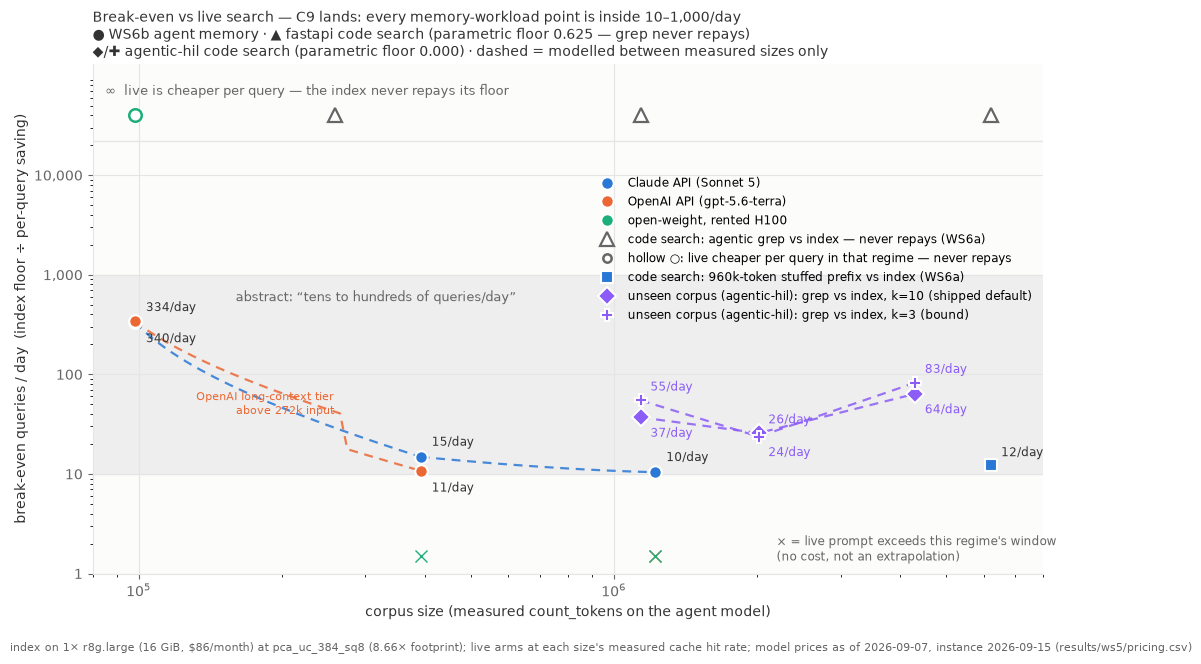

In [6]:
# ---- THE headline chart (C9): break-even queries/day vs corpus size, three regimes ----
# palette: dataviz reference slots 1-3 (validated all-pairs both modes); text/grid tokens
HUE = {"claude": "#2a78d6", "openai": "#eb6834", "open_weight": "#1baf7a"}
LABEL = {"claude": "Claude API (Sonnet 5)", "openai": "OpenAI API (gpt-5.6-terra)", "open_weight": "open-weight, rented H100"}
INK, INK2, GRID = "#333333", "#666666", "#e5e5e5"

fig, ax = plt.subplots(figsize=(11, 6.6))
ax.set_facecolor("#fcfcfb"); fig.patch.set_facecolor("white")
ax.set_xscale("log"); ax.set_yscale("log")

# the abstract's band
ax.axhspan(C9_BAND[0], C9_BAND[1], color="#eeeeee", zorder=0)
ax.text(1.6e5, 700, "abstract: “tens to hundreds of queries/day”", color=INK2, fontsize=9, va="top")

# --- memory workload (WS6b): measured points + MODELLED interpolation (dashed) ---
mem_live = {s: points[(points.workload=="memory")&(points["size"]==s)&(points.role=="live")].iloc[0] for s in "SML"}
mem_idx  = {s: points[(points.workload=="memory")&(points["size"]==s)&(points.role=="index")].iloc[0] for s in "SML"}
INF_Y = 4e4   # where "never repays" markers sit (off the numeric scale, labelled)
for regime in REGIMES:
    r = REGIMES[regime]
    sub = show[(show.workload=="memory")&(show.regime==regime)].sort_values("corpus_tokens")
    feas = sub[sub.feasible]
    # modelled line: replay cost is linear in prefix (arithmetic); memsearch cost interpolated log-linearly
    # between measured sizes; fixed cost from the measured chunk counts, interpolated log-linearly. Drawn ONLY
    # between measured sizes, never beyond.
    sizes = ["S", "M", "L"]
    for a, b in zip(sizes, sizes[1:]):
        la, lb = mem_live[a], mem_live[b]
        if not (sub.set_index("size").loc[a, "feasible"] and sub.set_index("size").loc[b, "feasible"]):
            continue
        xs = np.geomspace(la.corpus_tokens, lb.corpus_tokens, 40)
        t = (np.log(xs) - np.log(la.corpus_tokens)) / (np.log(lb.corpus_tokens) - np.log(la.corpus_tokens))
        ys = []
        for xi, ti in zip(xs, t):
            fit = np.interp(ti, [0, 1], [la.prefix_tokens / la.corpus_tokens, lb.prefix_tokens / lb.corpus_tokens])
            h = np.interp(ti, [0, 1], [la.hit_rate, lb.hit_rate])
            c_live = cost_model.live_query_cost(r, xi * fit, np.interp(ti,[0,1],[la.dynamic_tokens, lb.dynamic_tokens]),
                                         np.interp(ti,[0,1],[la.output_tokens, lb.output_tokens]), h)
            ia, ib = mem_idx[a], mem_idx[b]
            c_idx = cost_model.index_query_cost(r, np.exp(np.interp(ti,[0,1],[np.log(ia.dynamic_tokens), np.log(ib.dynamic_tokens)])),
                                         np.interp(ti,[0,1],[ia.output_tokens, ib.output_tokens]))
            nvec = np.exp(np.interp(ti,[0,1],[np.log(ia.n_vectors), np.log(ib.n_vectors)]))
            etok = np.exp(np.interp(ti,[0,1],[np.log(ia.embed_tokens), np.log(ib.embed_tokens)]))
            fake = pd.Series(dict(n_vectors=nvec, embed_tokens=etok))
            f = index_fixed(fake, HEADLINE_FOOTPRINT, HEADLINE_INFRA_MODE)["fixed_daily"]
            q = cost_model.break_even_qpd(c_live, c_idx, f)
            ys.append(np.nan if q is None else q)
        ax.plot(xs, ys, ls=(0, (4, 3)), lw=1.6, color=HUE[regime], alpha=0.85, zorder=2)
    ax.plot(feas.corpus_tokens, feas.break_even_qpd, "o", ms=9, color=HUE[regime], mec="white", mew=1.5, zorder=4,
            label=LABEL[regime])
    fin = feas[np.isfinite(feas.break_even_qpd)]
    for _, row in fin.iterrows():
        ax.annotate(f"{row.break_even_qpd:.0f}/day", (row.corpus_tokens, row.break_even_qpd),
                    xytext=(8, -15 if regime=="openai" else 8), textcoords="offset points", fontsize=8.5, color=INK)
    never = feas[~np.isfinite(feas.break_even_qpd)]
    ax.plot(never.corpus_tokens, [INF_Y]*len(never), "o", ms=9, mfc="white", mec=HUE[regime], mew=1.8, zorder=4)
    infeas = sub[~sub.feasible]
    for _, row in infeas.iterrows():
        ax.plot(row.corpus_tokens, 1.5, marker="x", ms=8, color=HUE[regime], zorder=4)

# --- code workload (WS6a): agentic vs indexed → never repays; stuffed vs indexed at L ---
code_rows = show[(show.workload=="code")&(show.regime=="claude")]
ag = code_rows[code_rows.live_arm=="agentic"]
ax.plot(ag.corpus_tokens, [INF_Y]*len(ag), marker="^", ls="none", ms=10, mfc="white", mec=INK2, mew=1.6, zorder=4,
        label="code search: agentic grep vs index — never repays (WS6a)")
ax.plot([], [], "o", mfc="white", mec=INK2, mew=1.8, label="hollow ○: live cheaper per query in that regime — never repays")
st = code_rows[code_rows.live_arm=="stuffed"]
ax.plot(st.corpus_tokens, st.break_even_qpd, marker="s", ls="none", ms=9, color=HUE["claude"], mec="white", mew=1.5, zorder=4,
        label="code search: 960k-token stuffed prefix vs index (WS6a)")
for _, row in st.iterrows():
    ax.annotate(f"{row.break_even_qpd:.0f}/day", (row.corpus_tokens, row.break_even_qpd), xytext=(7, 6), textcoords="offset points", fontsize=8.5, color=INK)

# --- WS9: the UNSEEN corpus, both top-k arms (the honest code-search curve) ---
UNSEEN_HUE = "#8b5cf6"
MARK = {"indexed": "D", "indexed_topk3": "P"}
KLAB = {"indexed": "k=10 (shipped default)", "indexed_topk3": "k=3 (bound)"}
un = show[(show.workload == "code_unseen") & (show.regime == "claude")]
for idx_arm in ("indexed", "indexed_topk3"):
    d = un[un.index_arm == idx_arm].sort_values("corpus_tokens")
    fin_d = d[d.break_even_qpd.notna() & np.isfinite(d.break_even_qpd.astype(float))]
    # dashed modelled line BETWEEN measured sizes only, never beyond
    if len(fin_d) > 1:
        ax.plot(fin_d.corpus_tokens, fin_d.break_even_qpd, ls=(0, (4, 3)), lw=1.6,
                color=UNSEEN_HUE, alpha=0.85, zorder=2)
    ax.plot(fin_d.corpus_tokens, fin_d.break_even_qpd, marker=MARK[idx_arm],
            ls="none", ms=9, color=UNSEEN_HUE, mec="white", mew=1.4, zorder=5,
            label=f"unseen corpus (agentic-hil): grep vs index, {KLAB[idx_arm]}")
    for _, row in fin_d.iterrows():
        # The two arms sit ~30px apart on this axis at L (68 vs 102/day), so a
        # fixed per-arm offset puts each label beside the OTHER arm's marker.
        # Label the higher arm at each size above its marker, the lower below.
        other = un[(un.index_arm != idx_arm) & (un["size"] == row["size"])].break_even_qpd
        other_higher = (len(other) > 0 and other.iloc[0] is not None
                        and np.isfinite(float(other.iloc[0]))
                        and float(other.iloc[0]) > row.break_even_qpd)
        ax.annotate(f"{row.break_even_qpd:.0f}/day",
                    (row.corpus_tokens, row.break_even_qpd),
                    xytext=(7, -14 if other_higher else 7),
                    textcoords="offset points", fontsize=8.5, color=UNSEEN_HUE)
    never = d[~(d.break_even_qpd.notna()
                & np.isfinite(d.break_even_qpd.astype(float)))]
    ax.plot(never.corpus_tokens, [INF_Y] * len(never), marker=MARK[idx_arm],
            ls="none", ms=9, mfc="white", mec=UNSEEN_HUE, mew=1.8, zorder=5)

ax.axhline(INF_Y/1.8, color=GRID, lw=1); ax.text(8.5e4, INF_Y*1.6, "∞  live is cheaper per query — the index never repays its floor", color=INK2, fontsize=9)
ax.text(2.2e6, 1.35, "× = live prompt exceeds this regime's window\n(no cost, not an extrapolation)", color=INK2, fontsize=8.5)
ax.annotate("OpenAI long-context tier\nabove 272k input", (OPENAI["long_context_threshold"], 40), xytext=(-8, 0), textcoords="offset points",
            ha="right", fontsize=8, color=HUE["openai"])

ax.set_xlabel("corpus size (measured count_tokens on the agent model)", color=INK)
ax.set_ylabel("break-even queries / day  (index floor ÷ per-query saving)", color=INK)
ax.set_ylim(1, 1.3e5); ax.set_xlim(8e4, 8e6)
ax.set_yticks([1, 10, 100, 1000, 1e4]); ax.set_yticklabels(["1", "10", "100", "1,000", "10,000"])
ax.grid(True, which="major", color=GRID, lw=0.8); ax.grid(False, which="minor")
for s in ("top", "right"): ax.spines[s].set_visible(False)
for s in ("left", "bottom"): ax.spines[s].set_color(GRID)
ax.tick_params(colors=INK2)
verdict_txt = ("C9 lands: every memory-workload point is inside 10–1,000/day" if C9_VERDICT
               else "C9 does NOT land at every size — see break_even.csv")
ax.set_title(f"Break-even vs live search — {verdict_txt}\n"
             "● WS6b agent memory · ▲ fastapi code search (parametric floor 0.625 — grep never repays)\n"
             "◆/✚ agentic-hil code search (parametric floor 0.000) · dashed = modelled between measured sizes only",
             fontsize=10, color=INK, loc="left")
fig.text(0.01, 0.005, esc(f"index on 1× {INSTANCE['sku']} ({INSTANCE['gib']} GiB, ${INSTANCE['usd_per_hour']*cost_model.HOURS_PER_MONTH:.0f}/month) at pca_uc_384_sq8 (8.66× footprint); "
                          f"live arms at each size's measured cache hit rate; model prices as of {FETCHED}, instance {INSTANCE_FETCHED} (results/ws5/pricing.csv)"), fontsize=8, color=INK2)
ax.legend(loc="upper right", bbox_to_anchor=(1.0, 0.80), fontsize=8.5, frameon=False)
fig.tight_layout(rect=(0, 0.03, 1, 1)); fig.savefig(OUT / "chart_break_even.png", dpi=160); manifest.record(OUT / "chart_break_even.png")
plt.show()


## C15 — when live search wins: update frequency

Churn enters the model on **both** sides, and the honest chart shows both:

- **Index side:** re-embedding. Cost/day = churn fraction × corpus embed
  tokens × re-embed factor × $0.02/MTok. The factor is **measured**: 1 for
  appends (99.97% skip), 5 for a mid-file edit (99.83% skip — line numbers
  are inside memsearch's chunk id, so everything after the edit in that
  file is re-embedded). An embedding-model migration is a **one-off full
  re-index at 0% skip** (the model name is in the chunk id) — it is the
  original build cost again, not a rate.
- **Live side:** a change that lands *inside* the cached prefix invalidates
  it. Append-only history keeps the prefix; an edit does not. The chart's
  second variant prices the live arm with the cache lost ($h = 0$, 1h
  write) as the bracket's other end.

Three corners are called out on the chart with measured numbers: small-N
where amortisation never repays, high churn where re-embedding dominates
(and under which infra mode it can), and in-training-data — WS6a's
parametric arm at **0.625** judge accuracy with no repository access, the
measured worked example.


churn fraction/day at which re-embedding equals the rest of the index's daily cost (>1 = never):
  dedicated {'S': {'append': np.float64(2828.5879), 'mid_edit': np.float64(565.7176)}, 'M': {'append': np.float64(701.2844), 'mid_edit': np.float64(140.2569)}, 'L': {'append': np.float64(224.4022), 'mid_edit': np.float64(44.8804)}}
  marginal  {'S': {'append': np.float64(0.041), 'mid_edit': np.float64(0.0082)}, 'M': {'append': np.float64(0.0404), 'mid_edit': np.float64(0.0081)}, 'L': {'append': np.float64(0.0401), 'mid_edit': np.float64(0.008)}}
model-migration one-off (full re-embed, 0% skip) = original build cost: {'S': np.float64(0.001), 'M': np.float64(0.004), 'L': np.float64(0.0126)}


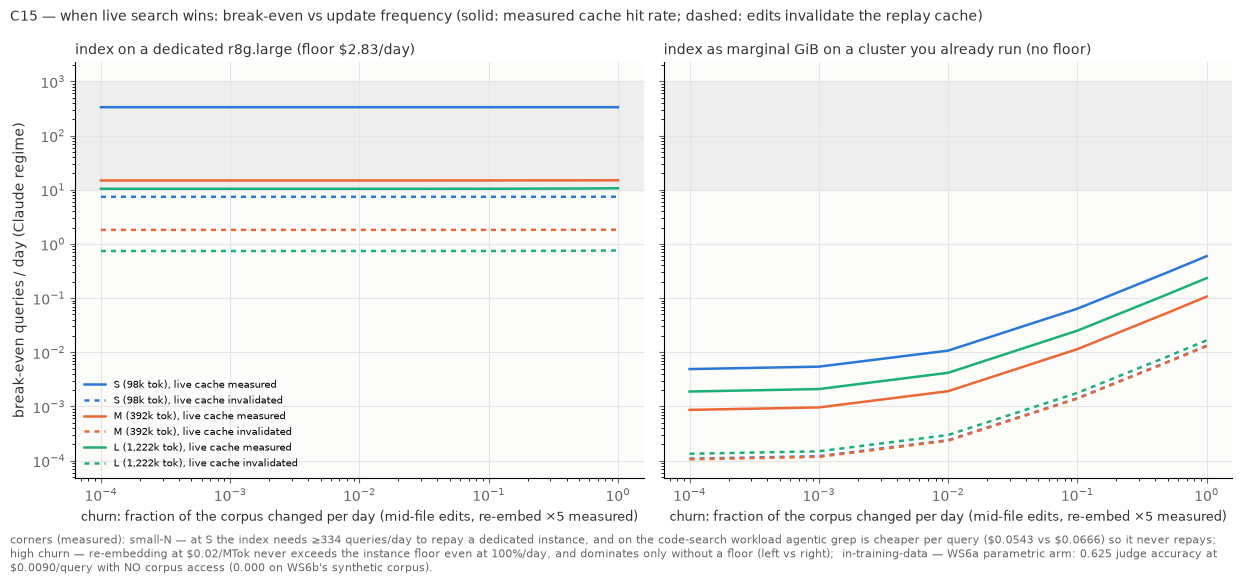

In [7]:
# ---- churn sweep -> churn.csv + chart ---------------------------------------
# Two workloads now. The index arm on the unseen corpus is `indexed` (the
# SHIPPED default) -- churn is a property of the corpus and the embedding, not
# of the query-time top-k, so pricing both top-k arms here would be two copies
# of one curve.
unseen_live = {s: points[(points.workload == "code_unseen")
                         & (points["size"] == s) & (points.arm == "agentic")].iloc[0]
               for s in "SML"}
unseen_idx  = {s: points[(points.workload == "code_unseen")
                         & (points["size"] == s) & (points.arm == "indexed")].iloc[0]
               for s in "SML"}
CHURN_PAIRS = ([("memory", s, mem_live[s], mem_idx[s]) for s in "SML"]
               + [("code_unseen", s, unseen_live[s], unseen_idx[s]) for s in "SML"])

churn_rows = []
for workload, size, live, idx in CHURN_PAIRS:
    for infra_mode in INFRA_MODES:
        for f in CHURN_SWEEP:
            for edit_kind, factor in REEMBED_FACTOR.items():
                for live_cache in ("measured", "invalidated"):
                    h = live.hit_rate if live_cache == "measured" else 0.0
                    row = be_row(live, idx, "claude", h, HEADLINE_FOOTPRINT,
                                 infra_mode, churn_frac=f, reembed=factor)
                    churn_rows.append({**row, "workload": workload,
                                       "churn_frac_per_day": f,
                                       "edit_kind": edit_kind,
                                       "live_cache": live_cache})
churn = pd.DataFrame(churn_rows)
churn["reembed_share_of_fixed"] = churn.churn_day / churn.fixed_daily
churn.to_csv(OUT / "churn.csv", index=False); manifest.record(OUT / "churn.csv")

# corner 2: at what churn does re-embedding exceed the rest of the fixed cost?
def churn_star(size, infra_mode, factor):
    live, idx = mem_live[size], mem_idx[size]
    base = index_fixed(idx, HEADLINE_FOOTPRINT, infra_mode)
    other = base["fixed_daily"]
    per_unit = cost_model.churn_daily_usd(idx.embed_tokens, 1.0, EMBED_USD_PER_MTOK, factor)
    return other / per_unit   # fraction/day at which churn_day == the rest; >1 means never
print("churn fraction/day at which re-embedding equals the rest of the index's daily cost (>1 = never):")
for infra_mode in INFRA_MODES:
    print(f"  {infra_mode:9s}", {s: {k: round(churn_star(s, infra_mode, v), 4) for k, v in REEMBED_FACTOR.items()} for s in "SML"})

# corner 1 + 3, numbers for the chart text
q_s = show[(show.workload=="memory")&(show.regime=="claude")&(show["size"]=="S")].break_even_qpd.iloc[0]
par = points[(points.workload=="code")&(points.arm=="parametric")].iloc[0]
migration = {s: round(mem_idx[s].embed_cost_measured, 4) for s in "SML"}
print("model-migration one-off (full re-embed, 0% skip) = original build cost:", migration)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.4), sharey=True)
xs = [c for c in CHURN_SWEEP if c > 0]
for ax, infra_mode in zip(axes, INFRA_MODES):
    ax.set_facecolor("#fcfcfb"); ax.set_xscale("log"); ax.set_yscale("log")
    ax.axhspan(C9_BAND[0], C9_BAND[1], color="#eeeeee", zorder=0)
    hue_size = {"S": HUE["claude"], "M": HUE["openai"], "L": HUE["open_weight"]}
    for size in "SML":
        for live_cache, ls in (("measured", "-"), ("invalidated", (0, (2, 2)))):
            d = churn[(churn.workload=="memory")&(churn["size"]==size)&(churn.infra_mode==infra_mode)&(churn.edit_kind=="mid_edit")&(churn.live_cache==live_cache)&(churn.churn_frac_per_day>0)]
            ax.plot(d.churn_frac_per_day, d.break_even_qpd, ls=ls, lw=1.8, color=hue_size[size],
                    label=f"{size} ({mem_live[size].corpus_tokens/1e3:,.0f}k tok), live cache {live_cache}" )
    ax.set_xlabel("churn: fraction of the corpus changed per day (mid-file edits, re-embed ×5 measured)", color=INK, fontsize=9)
    ax.set_title(esc("index on a dedicated %s (floor $%.2f/day)" % (INSTANCE["sku"], INSTANCE["usd_per_hour"]*24)) if infra_mode=="dedicated"
                 else "index as marginal GiB on a cluster you already run (no floor)", fontsize=10, color=INK, loc="left")
    ax.grid(True, which="major", color=GRID, lw=0.8); ax.grid(False, which="minor")
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    ax.tick_params(colors=INK2)
axes[0].set_ylabel("break-even queries / day (Claude regime)", color=INK)
axes[0].legend(fontsize=7.5, frameon=False, loc="lower left", ncol=1)
corner = (f"corners (measured): small-N — at S the index needs ≥{q_s:.0f} queries/day to repay a dedicated instance, and on the code-search workload "
          f"agentic grep is cheaper per query (${points[(points.workload=='code')&(points.arm=='agentic')&(points['size']=='L')].measured_mean_billed.iloc[0]:.4f} vs "
          f"${points[(points.workload=='code')&(points.arm=='indexed')&(points['size']=='L')].measured_mean_billed.iloc[0]:.4f}) so it never repays;  "
          f"high churn — re-embedding at $0.02/MTok never exceeds the instance floor even at 100%/day, and dominates only without a floor (left vs right);  "
          f"in-training-data — WS6a parametric arm: {par.judge_accuracy:.3f} judge accuracy at ${par.measured_mean_billed:.4f}/query with NO corpus access (0.000 on WS6b's synthetic corpus).")
fig.suptitle("C15 — when live search wins: break-even vs update frequency (solid: measured cache hit rate; dashed: edits invalidate the replay cache)", fontsize=10, x=0.01, ha="left", color=INK)
fig.text(0.01, -0.06, esc(corner), fontsize=8, color=INK2, wrap=True)
fig.tight_layout(); fig.savefig(OUT / "chart_churn.png", dpi=160, bbox_inches="tight"); manifest.record(OUT / "chart_churn.png")
plt.show()


## C13 — sensitivity: which knobs move the verdict, and which don't

Base case = the headline (Claude regime, measured hit rate, dedicated
`r8g.large`, `pca_uc_384_sq8`) at each measured size of each workload:
WS6b memory at S/M/L, and the WS9 unseen corpus at S/M/L (agentic grep vs
`indexed`, the shipped top-k). Knobs are ranked *within* a workload; the
tornado below shows the memory workload. Each knob is moved on its own:

| knob | settings |
|---|---|
| Claude price (input, output and cache rates together) | ×0.5, ×1.5 |
| cache hit rate | miss rate ÷2, miss rate ×2 (a 0.97 hit rate cannot be doubled — the miss rate can) |
| infra $/GiB-month (instance price) | ×0.5, ×2 |
| footprint | `pca_uc_384_sq8` 8.66× vs `sq8` 3.54× (and `refine_k2` 3.11×) |
| *extra:* infra mode | dedicated floor vs marginal GiB |
| *extra:* cache TTL | 1h write (2×, as run) vs 5m write (1.25×) |
| *extra:* live arm uncached | list price (the strawman) |
| *extra:* open-weight $/MTok | ×0.5, ×2 (prefill/decode asymmetry) |

Direction matters. A knob **weakens** the claim if, at any size, it pushes
$Q^*$ *above* 1000/day, flips the per-query winner (index stops winning),
or makes the live point infeasible. A knob that pushes $Q^*$ *below* 10/day
**strengthens** it (the index repays at single-digit volumes) — that is
reported, not counted against the claim. Knobs are ranked by the spread
(max/min) of $Q^*$ they induce.


size                                                              S      M       L
workload    knob                     setting                                      
memory      base                     headline                 333.8   14.8    10.4
            claude_price             x0.5                     667.5   29.7    20.8
                                     x1.5                     222.5    9.9     6.9
            cache_hit_rate           miss/2                   333.8   22.0    12.7
                                     miss x2                  333.8    9.0     7.7
            infra_usd_per_gib_month  x0.5                     166.9    7.4     5.2
                                     x2                       667.5   29.7    20.8
            footprint                sq8 3.54x                333.8   14.8    10.4
                                     refine_k2 3.11x          333.8   14.8    10.4
            infra_mode               marginal GiB (no floor)    0.0    0.0     0.0
    

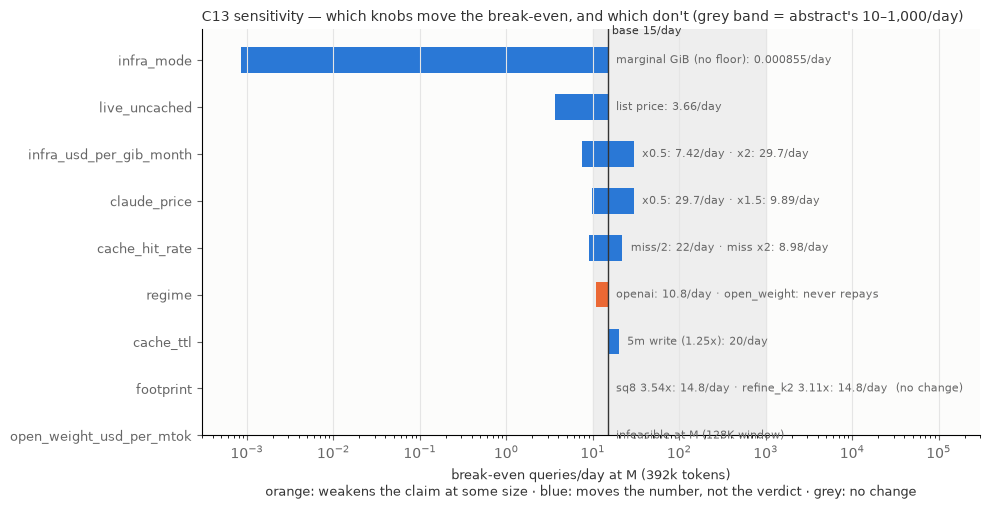

In [8]:
# ---- sensitivity table → sensitivity.csv + tornado --------------------------------------
SENS_PAIRS = {"memory": (mem_live, mem_idx),
              "code_unseen": (unseen_live, unseen_idx)}

def q_for(workload, size, *, price_mult=1.0, miss_mult=1.0, infra_mult=1.0,
          footprint=HEADLINE_FOOTPRINT, infra_mode=HEADLINE_INFRA_MODE,
          write_mult=None, cached=True, regime="claude"):
    live_d, idx_d = SENS_PAIRS[workload]
    live, idx = live_d[size], idx_d[size]
    base = REGIMES[regime]
    r = cost_model.Regime(base.name, base.model, base.input_usd_per_mtok*price_mult, base.output_usd_per_mtok*price_mult,
                   base.cache_write_multiplier if write_mult is None else write_mult, base.cache_read_multiplier,
                   base.context_window_tokens, base.long_context_threshold,
                   None if base.long_input_usd_per_mtok is None else base.long_input_usd_per_mtok*price_mult,
                   None if base.long_cached_usd_per_mtok is None else base.long_cached_usd_per_mtok*price_mult,
                   None if base.long_output_usd_per_mtok is None else base.long_output_usd_per_mtok*price_mult)
    h = cost_model.stretch_hit_rate(live.hit_rate, miss_mult)
    c_live = cost_model.live_query_cost(r, live.prefix_tokens, live.dynamic_tokens, live.output_tokens, h, cached=cached)
    c_idx = cost_model.index_query_cost(r, idx.dynamic_tokens, idx.output_tokens)
    f = index_fixed(idx, footprint, infra_mode, usd_per_hour=INSTANCE["usd_per_hour"]*infra_mult)["fixed_daily"]
    return cost_model.break_even_qpd(c_live, c_idx, f), c_live, c_idx, f

KNOBS = [
  ("base", "headline", {}),
  ("claude_price", "x0.5", dict(price_mult=0.5)), ("claude_price", "x1.5", dict(price_mult=1.5)),
  ("cache_hit_rate", "miss/2", dict(miss_mult=0.5)), ("cache_hit_rate", "miss x2", dict(miss_mult=2.0)),
  ("infra_usd_per_gib_month", "x0.5", dict(infra_mult=0.5)), ("infra_usd_per_gib_month", "x2", dict(infra_mult=2.0)),
  ("footprint", "sq8 3.54x", dict(footprint="sq8")), ("footprint", "refine_k2 3.11x", dict(footprint="refine_k2")),
  ("infra_mode", "marginal GiB (no floor)", dict(infra_mode="marginal")),
  ("cache_ttl", "5m write (1.25x)", dict(write_mult=CLAUDE["cache_write_5m_mult"])),
  ("live_uncached", "list price", dict(cached=False)),
  ("open_weight_usd_per_mtok", "x0.5", dict(regime="open_weight", price_mult=0.5)),
  ("open_weight_usd_per_mtok", "x2", dict(regime="open_weight", price_mult=2.0)),
  ("regime", "openai", dict(regime="openai")),
  ("regime", "open_weight", dict(regime="open_weight")),
]
sens = []
for workload in SENS_PAIRS:
    for knob, setting, kw in KNOBS:
        for size in "SML":
            q, cl, ci, f = q_for(workload, size, **kw)
            sens.append(dict(workload=workload, knob=knob, setting=setting, size=size,
                             corpus_tokens=SENS_PAIRS[workload][0][size].corpus_tokens,
                             c_live=cl, c_index_query=ci, fixed_daily=f, break_even_qpd=q,
                             in_c9_band=None if q is None else (C9_BAND[0] <= q < C9_BAND[1]),
                             index_wins_per_query=None if cl is None else (cl > ci),
                             feasible=q is not None))
sens = pd.DataFrame(sens)
base_q = sens[sens.knob == "base"].set_index(["workload", "size"]).break_even_qpd
sens["ratio_vs_base"] = sens.apply(
    lambda r: None if r.break_even_qpd is None or not np.isfinite(r.break_even_qpd)
    else r.break_even_qpd / base_q[(r.workload, r["size"])], axis=1)

# Ranking is computed WITHIN a workload. Ranking across them would silently
# rewrite the memory rows' max_spread_ratio -- the numbers the deck's
# SOURCES.md documents knob by knob.
rank = []
for workload in SENS_PAIRS:
    w = sens[sens.workload == workload]
    for knob in w.knob.unique():
        if knob == "base": continue
        d = pd.concat([w[w.knob==knob], w[w.knob=="base"]])
        d = d[d.feasible & np.isfinite(d.break_even_qpd.astype(float))]
        spread = (d.groupby("size").break_even_qpd.max()
                  / d.groupby("size").break_even_qpd.min()).max()
        k = w[w.knob==knob]
        qs = k.break_even_qpd.astype(float)
        above = bool((qs >= C9_BAND[1]).any()); below = bool((qs < C9_BAND[0]).any())
        flips_winner = (~k.index_wins_per_query.fillna(True).astype(bool)).any()
        infeasible = (~k.feasible).any()
        weakens = bool(above or flips_winner or infeasible)
        rank.append(dict(workload=workload, knob=knob,
                         max_spread_ratio=round(float(spread), 2),
                         pushes_above_1000=above, pushes_below_10=below,
                         flips_per_query_winner=bool(flips_winner),
                         some_size_infeasible=bool(infeasible),
                         weakens_claim=weakens,
                         strengthens_claim=bool(below and not weakens),
                         changes_number=bool(spread > 1.05)))
rank = pd.DataFrame(rank).sort_values(["workload", "max_spread_ratio"], ascending=[True, False])
sens = sens.merge(rank[["workload","knob","max_spread_ratio","weakens_claim",
                        "strengthens_claim","changes_number"]],
                  on=["workload","knob"], how="left")
sens.to_csv(OUT / "sensitivity.csv", index=False); manifest.record(OUT / "sensitivity.csv")

# workload in the pivot index: without it pivot_table would MEAN the two
# workloads' Q* together into one printed number per knob.
piv = sens.pivot_table(index=["workload","knob","setting"], columns="size", values="break_even_qpd", sort=False)[list("SML")]
print(piv.round(1).to_string()); print()
print(rank.to_string(index=False))
for workload, rw in rank.groupby("workload", sort=False):
    print(f"\n[{workload}] WEAKEN the claim (Q* above 1000, winner flips, or infeasible):", rw[rw.weakens_claim].knob.tolist())
    print(f"[{workload}] STRENGTHEN it (Q* drops below 10/day somewhere, i.e. 'tens' becomes 'single digits'):", rw[rw.strengthens_claim].knob.tolist())
    print(f"[{workload}] move the number but not the verdict:", rw[rw.changes_number & ~rw.weakens_claim & ~rw.strengthens_claim].knob.tolist())
    print(f"[{workload}] move nothing:", rw[~rw.changes_number].knob.tolist())

# tornado at M (the middle measured size), log axis -- the MEMORY workload, as before
fig, ax = plt.subplots(figsize=(10, 5.2)); ax.set_facecolor("#fcfcfb"); ax.set_xscale("log")
sizeM = sens[(sens["size"]=="M") & (sens.workload=="memory")]
bq = float(base_q[("memory", "M")])
ordered = list(rank[rank.workload=="memory"].knob)
for i, knob in enumerate(ordered):
    d = sizeM[sizeM.knob==knob]
    vals = [v for v in d.break_even_qpd if v is not None and np.isfinite(v)]
    if not vals:
        ax.text(bq*1.25, i, "infeasible at M (128K window)", va="center", fontsize=8, color=INK2); continue
    lo, hi = min(vals + [bq]), max(vals + [bq])
    rk = rank[rank.workload=="memory"].set_index("knob").loc[knob]
    ax.barh(i, hi - lo, left=lo, height=0.55, color=HUE["openai"] if rk.weakens_claim else (HUE["claude"] if rk.changes_number else "#bbbbbb"))
    parts = [f"{row.setting}: {row.break_even_qpd:.3g}/day" if (row.break_even_qpd is not None and np.isfinite(row.break_even_qpd))
             else f"{row.setting}: never repays" for _, row in d.iterrows()]
    ax.text(max(hi, bq) * 1.25, i, " · ".join(parts) + ("" if hi > lo else "  (no change)"), va="center", fontsize=8, color=INK2)
ax.axvline(bq, color=INK, lw=1); ax.text(bq * 1.12, -0.55, f"base {bq:.0f}/day", fontsize=8, color=INK, ha="left")
ax.set_xlim(3e-4, 3e5)
ax.axvspan(C9_BAND[0], C9_BAND[1], color="#eeeeee", zorder=0)
ax.set_yticks(range(len(ordered))); ax.set_yticklabels(ordered, fontsize=9); ax.invert_yaxis()
ax.set_xlabel("break-even queries/day at M (392k tokens)\norange: weakens the claim at some size · blue: moves the number, not the verdict · grey: no change", color=INK, fontsize=9)
ax.set_title("C13 sensitivity — which knobs move the break-even, and which don't (grey band = abstract's 10–1,000/day)", fontsize=10, color=INK, loc="left")
ax.grid(True, axis="x", color=GRID, lw=0.8); ax.grid(False, which="minor")
for s in ("top", "right"): ax.spines[s].set_visible(False)
ax.tick_params(colors=INK2)
fig.tight_layout(); fig.savefig(OUT / "chart_sensitivity.png", dpi=160); manifest.record(OUT / "chart_sensitivity.png")
plt.show()


## LIMITS — what a hostile reader checks first

1. **Three workloads, two repositories, one synthetic history.** The memory
   points are WS6b's synthetic corpus (n = 12/12/38); the code points are
   `fastapi` (n = 40, scaling subsets n = 10) and, on the unseen corpus,
   `agentic-hil` (a 37-question panel at each of S/M/L; the parametric floor
   at L only). No confidence intervals across corpora; the dashed lines are
   modelled between measured sizes and stop at them.
2. **Token counts were measured on Claude's tokenizer.** The OpenAI and
   open-weight regimes re-price the *same* counts; their tokenizers would
   give different counts (WS6a measured tiktoken 26% *below* Claude on the
   repo). Direction: the non-Claude regimes are overstated by up to ~1.3×
   on input, which flatters the index under those regimes.
3. **The open-weight $/MTok is a derivation, not a quote**: one benchmark
   (Llama 3.3 70B FP8, vLLM, 1× H100, 50 concurrent) and one rental price,
   blended over input and output, at 100% utilisation, with prefix-cache
   hits assumed free and no ops labour. A 128K window means only the S
   memory point and the agentic code points fit; a 1M-context open model
   needs its own benchmark.
3. **The instance floor is the load-bearing assumption.** With a dedicated
   `r8g.large` the break-even is tens-to-hundreds/day; on a cluster you
   already run it is a query every few months. Managed serverless pricing
   sits between the two and was not modelled.
4. **Laptop latency is excluded** (WS2/WS3/WS6b numbers are single-node
   Docker; WS6a's index was Zilliz Cloud). Nothing here prices time.
5. **The footprint multipliers were measured at 10M × 1024d on
   `mxbai-embed-large-v1`** and applied as ratios to 1536d
   `text-embedding-3-small` vectors. At WS6's corpus sizes (2 MB of index)
   the choice cannot matter; it starts to matter when the index outgrows an
   instance (~9.9M vectors at 3.54×, ~24M at 8.66× on 16 GiB).
6. **Prices are as of 2026-09-07** (`pricing.csv` carries every URL). Claude
   Sonnet 5's $2/$10 was re-verified; the page states it is now permanent.
7. **Judge cost is excluded** from every per-query figure (it is a benchmark
   cost, not a production one), and WS6a's output tokens include adaptive
   thinking, identical across arms.
8. **Cache TTL:** WS6 ran with 1h writes (2×). A 5m cache (1.25×) is
   cheaper for the live arm and is in the sensitivity table.
